# 01 — Exploratory Data Analysis (EDA)
**Project:** Predicting Ligue 1 Player Market Values  
**Dataset:** EA Sports FC 24 — `male_players.csv`  
**Target variable:** `value_eur` (player market value in euros)

---

## What is EDA and why do we do it?

Exploratory Data Analysis is the **first mandatory step** in any machine learning pipeline.  
Before training any model, we need to understand:
1. **What the data looks like** — shape, types, missing values
2. **How the target variable is distributed** — is it skewed? Does it have outliers?
3. **Which features correlate with the target** — this guides feature selection (notebook 02)
4. **Are there outliers?** — extreme values can distort model training

Think of EDA as the *diagnosis before the surgery*.

## Step 1 — Import Libraries

In [24]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent visual style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Step 2 — Load the Dataset and Filter Ligue 1

The raw CSV contains **180,021 rows** from multiple leagues and FIFA versions.  
We filter to `league_name == 'Ligue 1'` to isolate only French top-flight players.

**Why filter early?**  
Market value dynamics differ by league (salary caps, transfer policies, prestige).  
Mixing leagues would add confounding variance that hurts model accuracy for Ligue 1 specifically.

**Why `.copy()`?**  
After filtering, pandas still tracks that `df` is a slice of `df_raw`.  
Calling `.copy()` creates a fully independent DataFrame and prevents `SettingWithCopyWarning`  
when we modify the data later.

In [25]:
# low_memory=False prevents pandas from guessing column dtypes mid-file
df_raw = pd.read_csv('../data/male_players.csv', low_memory=False)

print(f'Full dataset shape: {df_raw.shape}')  # (rows, columns)
print(f'Unique leagues: {df_raw["league_name"].nunique()}')
print()

# The string in the dataset is 'Ligue 1', not 'French Ligue 1'
df = df_raw[df_raw['league_name'] == 'Ligue 1'].copy()

print(f'Ligue 1 dataset shape: {df.shape}')
print(f'FIFA versions covered: {sorted(df["fifa_version"].unique())}')

Full dataset shape: (180021, 109)
Unique leagues: 42

Ligue 1 dataset shape: (5088, 109)
FIFA versions covered: [np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0)]


## Step 3 — Basic Data Inspection

Three standard inspection tools:
- `.head()` → see actual row examples, confirm data loaded correctly
- `.info()` → column types (int, float, object) and non-null counts — reveals structural issues
- `.describe()` → summary statistics — reveals scale, spread, and potential outliers via std

**What to watch for:**
- Columns with many nulls → decide to drop or impute
- `object` columns that look numeric → may need conversion
- Mean >> median → right-skewed distribution (likely for `value_eur`)

In [26]:
df.head()

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_id,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined_date,club_contract_valid_until_year,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
1,11,https://sofifa.com/player/11/romain-rocchi/150002,15.0,2.0,2014-09-18,R. Rocchi,Romain Rocchi,"CM, CDM",68,68,675000.0,8000.0,32,1981-10-02,183,75,68.0,Metz,16.0,Ligue 1,1.0,RDM,7.0,NaN,2013-07-01,2015.0,18,France,NaN,NaN,NaN,Right,3,3,1,Medium/High,Normal (170-185),No,NaN,NaN,Finesse Shot,52.0,62.0,69.0,68.0,56.0,69.0,64,54,60,73,61,65,69,49,69,73,53,52,74,68,63,72,70,54,79,71,63,63,64,72,65,NaN,46,59,57,6,7,10,7,12,NaN,63,63,63,66,66,66,66,66,69-1,69-1,69-1,66,68,68,68,66,62,65,65,65,62,60,62,62,62,60,12
31,2147,https://sofifa.com/player/2147/maarten-stekele...,15.0,2.0,2014-09-18,M. Stekelenburg,Maarten Stekelenburg,GK,77,77,4700000.0,50000.0,31,1982-09-22,197,92,69.0,Monaco,16.0,Ligue 1,1.0,SUB,16.0,Fulham,NaN,2015.0,34,Netherlands,NaN,NaN,NaN,Right,4,1,2,Medium/Medium,Lean (185+),No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,25,25,38,25,25,25,25,36,30,35,45,35,72,27,25,55,30,77,25,40,25,25,25,22,NaN,25,25,25,80,74,81,75,78,41.0,33,33,33,32,32,32,32,32,32,32,32,33,33,33,33,33,32,37,37,37,32,32,36,36,36,32,77
39,2488,https://sofifa.com/player/2488/zoumana-camara/...,15.0,2.0,2014-09-18,Z. Camara,Zoumana Camara,CB,73,73,400000.0,45000.0,35,1979-04-03,182,76,73.0,Paris Saint Germain,16.0,Ligue 1,1.0,SUB,6.0,NaN,2007-01-01,2015.0,18,France,NaN,NaN,NaN,Right,3,2,2,Low/Medium,Normal (170-185),Yes,NaN,NaN,NaN,59.0,35.0,55.0,59.0,73.0,71.0,42,27,74,70,30,54,49,33,53,63,53,63,62,67,62,57,84,55,76,30,75,64,22,52,50,NaN,76,77,72,14,10,11,8,12,NaN,48,48,48,51,49,49,49,51,52,52,52,54,56,56,56,54,64,66,66,66,64,67,73,73,73,67,14
53,3622,https://sofifa.com/player/3622/ricardo-alberto...,15.0,2.0,2014-09-18,Ricardo Carvalho,Ricardo Alberto Silveira de Carvalho,CB,77,77,NaN,35000.0,36,1978-05-18,181,78,69.0,Monaco,16.0,Ligue 1,1.0,RCB,6.0,NaN,2013-07-01,2015.0,38,Portugal,NaN,NaN,NaN,Right,3,2,3,Medium/Medium,Normal (170-185),Yes,NaN,NaN,Injury Prone,50.0,46.0,59.0,56.0,78.0,67.0,47,47,82,73,51,50,54,35,64,63,46,54,53,70,63,52,70,32,77,38,83,81,50,51,37,NaN,78,77,69,15,12,7,11,11,NaN,56+1,56+1,56+1,54+1,55+1,55+1,55+1,54+1,56+1,56+1,56+1,56+1,61+1,61+1,61+1,56+1,64+1,69+1,69+1,69+1,64+1,69+1,76+1,76+1,76+1,69+1,16+1
69,4985,https://sofifa.com/player/4985/jerome-leroy/15...,15.0,2.0,2014-09-18,J. Leroy,Jérôme Leroy,CAM,70,70,170000.0,15000.0,39,1974-11-04,185,75,1738.0,Le Havre,17.0,Ligue 1,2.0,CAM,4.0,NaN,2014-08-22,2015.0,18,France,NaN,NaN,NaN,Right,4,3,2,Medium/Medium,Lean (185+),No,NaN,NaN,Playmaker (AI),56.0,63.0,74.0,70.0,32.0,53.0,74,64,59,77,73,71,70,67,70,74,59,54,56,67,57,69,64,43,57,51,53,47,68,75,71,NaN,23,24,28,9,5,9,8,6,NaN,65,65,65,69,66,66,66,69,70,70,70,69,65,65,65,69,52,56,5

In [27]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
Index: 5088 entries, 1 to 180011
Data columns (total 109 columns):
 #    Column                          Non-Null Count  Dtype  
---   ------                          --------------  -----  
 0    player_id                       5088 non-null   int64  
 1    player_url                      5088 non-null   str    
 2    fifa_version                    5088 non-null   float64
 3    fifa_update                     5088 non-null   float64
 4    update_as_of                    5088 non-null   str    
 5    short_name                      5088 non-null   str    
 6    long_name                       5088 non-null   str    
 7    player_positions                5088 non-null   str    
 8    overall                         5088 non-null   int64  
 9    potential                       5088 non-null   int64  
 10   value_eur                       5080 non-null   float64
 11   wage_eur                        5088 non-null   float64
 12   age                             

In [28]:
pd.set_option('display.max_columns', None)
# .T transposes — each column becomes a row, much easier to read with 109 features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
player_id,5088.0,216911.237421,34795.202868,11.0,200677.0,222699.0,239203.0,278119.0
fifa_version,5088.0,19.502752,2.835853,15.0,17.0,19.0,22.0,24.0
fifa_update,5088.0,2.000000,0.000000,2.0,2.0,2.0,2.0,2.0
overall,5088.0,69.578616,7.032578,50.0,64.0,70.0,75.0,93.0
potential,5088.0,75.570362,5.753996,55.0,72.0,76.0,80.0,95.0
...,...,...,...,...,...,...,...,...
goalkeeping_handling,5088.0,16.786950,18.248256,2.0,8.0,11.0,14.0,87.0
goalkeeping_kicking,5088.0,16.708726,17.798803,2.0,8.0,11.0,14.0,82.0
goalkeeping_positioning,5088.0,16.975432,18.498056,3.0,8.0,11.0,14.0,90.0
goalkeeping_reflexes,5088.0,17.365173,19.556441,2.0,8.0,11.0,14.0,90.0


## Step 4 — Missing Value Analysis

Missing data is a fundamental ML problem — models cannot ingest NaN values.

**Our strategy:**
- **Target (`value_eur`):** Always **drop** rows with null. We cannot impute what we are trying to predict — that would leak the answer into training.
- **Feature columns:** We handle these in notebook 02 during feature selection (impute or drop based on the chosen features).

In [29]:
# Count missing values per column and compute percentage
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print('Columns with missing values:')
print(missing_df[missing_df['missing_count'] > 0].to_string())

Columns with missing values:
                      missing_count  missing_pct
club_loaned_from               4866        95.64
nation_jersey_number           4736        93.08
nation_position                4736        93.08
nation_team_id                 4736        93.08
player_tags                    4558        89.58
goalkeeping_speed              4506        88.56
player_traits                  2654        52.16
release_clause_eur             1645        32.33
mentality_composure             970        19.06
passing                         582        11.44
shooting                        582        11.44
pace                            582        11.44
physic                          582        11.44
dribbling                       582        11.44
defending                       582        11.44
club_joined_date                222         4.36
value_eur                         8         0.16


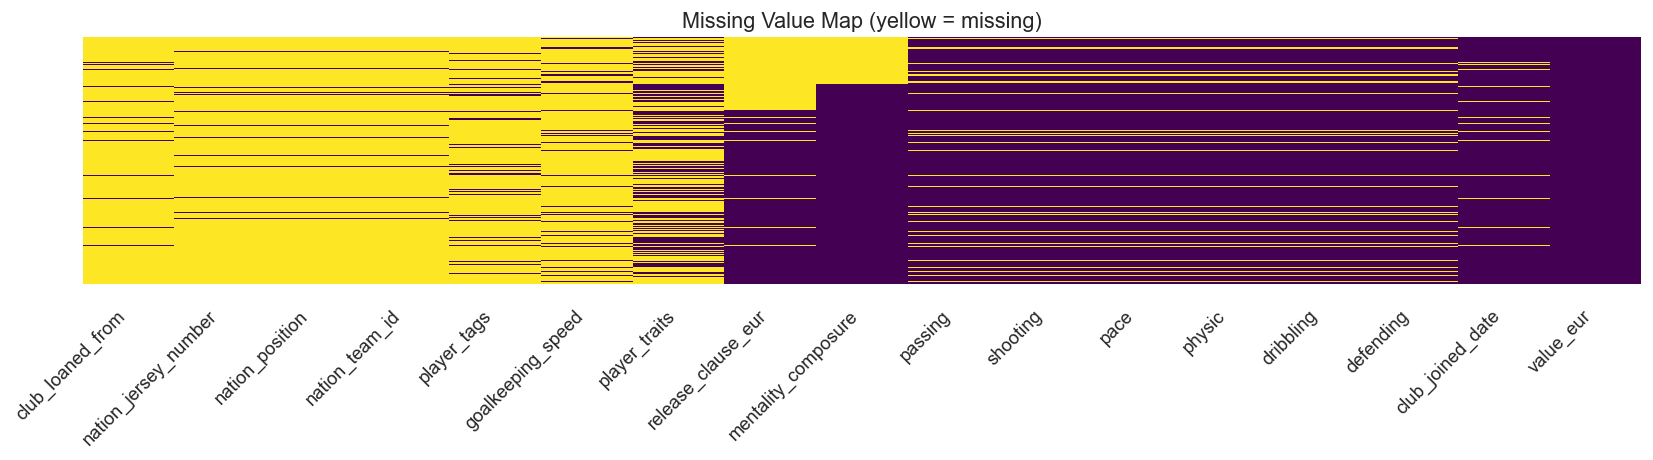

In [30]:
# Heatmap of missing values — yellow = missing, purple = present
top_missing_cols = missing_df[missing_df['missing_count'] > 0].head(20).index.tolist()

if top_missing_cols:
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(
        df[top_missing_cols].isnull(),
        cbar=False, yticklabels=False,
        cmap='viridis', ax=ax
    )
    ax.set_title('Missing Value Map (yellow = missing)', fontsize=13)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

In [31]:
# Drop rows where the target (value_eur) is null
before = len(df)
df = df.dropna(subset=['value_eur'])
after = len(df)

print(f'Rows before: {before}  |  Rows after: {after}  |  Dropped: {before - after}')

Rows before: 5088  |  Rows after: 5080  |  Dropped: 8


## Step 5 — Target Variable Distribution

### Why does distribution shape matter?

Most ML loss functions (MSE, MAE) penalize predictions proportionally.  
If the target is **heavily right-skewed**, the model is forced to focus on extreme values,  
producing poor predictions for the majority of average-valued players.

### Skewness (formal definition)
$$\text{Skewness} = \frac{E[(X - \mu)^3]}{\sigma^3}$$

- **Skewness ≈ 0** → symmetric (like a normal distribution)
- **Skewness > 1** → strong right skew → long right tail (few very high values)
- **Skewness < −1** → strong left skew

### Solution: log-transform
If skewness > 1, apply `np.log1p(x) = log(x + 1)`.  
This compresses the right tail and brings the distribution closer to normal.  
We will use log-transformed `value_eur` as the target in notebook 05 (FFNN).

In [32]:
skewness = df['value_eur'].skew()
kurt     = df['value_eur'].kurt()

print(f'Skewness : {skewness:.3f}  (>1 = strong right skew)')
print(f'Kurtosis : {kurt:.3f}  (>3 = heavier tails than normal)')
print()
if skewness > 1:
    print('Verdict: strong right skew detected — log-transform is strongly recommended.')

Skewness : 7.502  (>1 = strong right skew)
Kurtosis : 91.119  (>3 = heavier tails than normal)

Verdict: strong right skew detected — log-transform is strongly recommended.


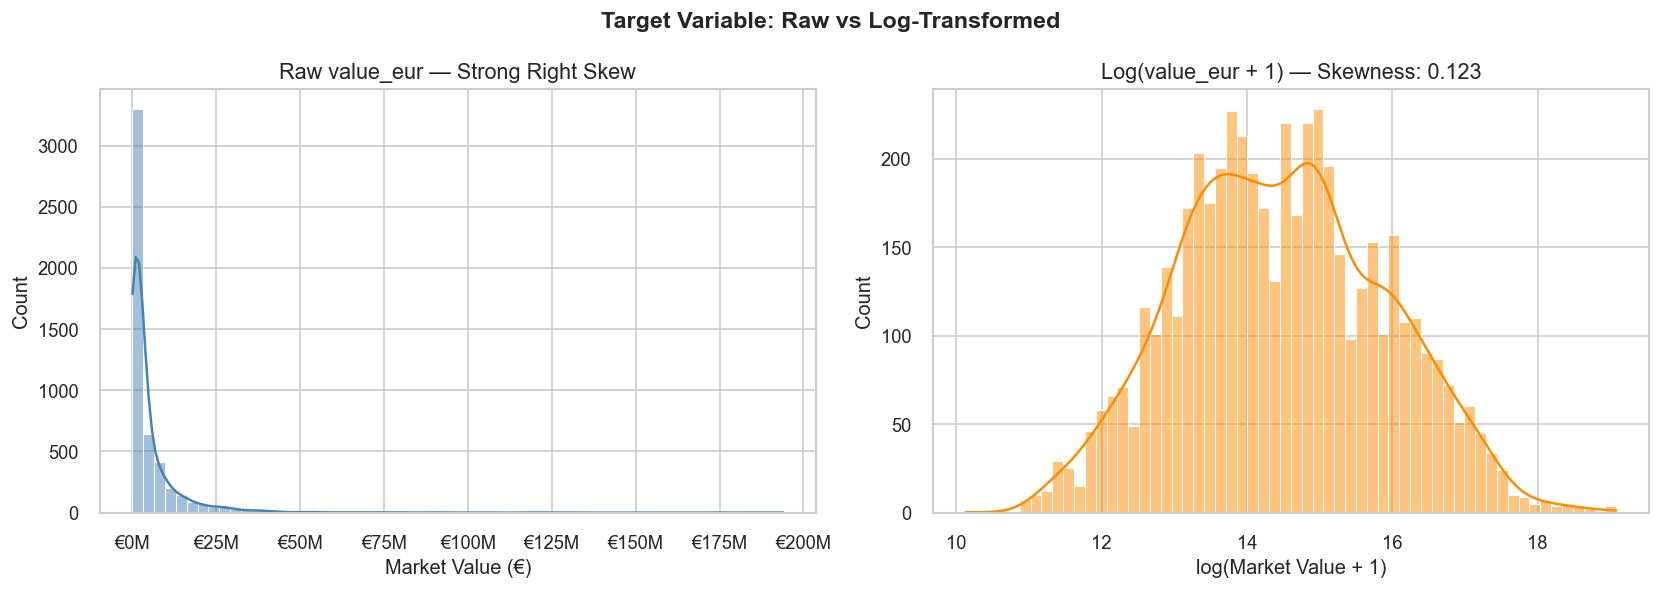

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
sns.histplot(df['value_eur'], kde=True, bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Raw value_eur — Strong Right Skew', fontsize=13)
axes[0].set_xlabel('Market Value (€)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1e6:.0f}M'))

# Log-transformed distribution
# np.log1p(x) = log(x+1) — safe for x=0; here value_eur > 0 but it's good practice
log_values = np.log1p(df['value_eur'])
sns.histplot(log_values, kde=True, bins=60, ax=axes[1], color='darkorange')
axes[1].set_title(f'Log(value_eur + 1) — Skewness: {log_values.skew():.3f}', fontsize=13)
axes[1].set_xlabel('log(Market Value + 1)')

plt.suptitle('Target Variable: Raw vs Log-Transformed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — Boxplot: Visualizing Outliers

A **boxplot** (a.k.a. box-and-whisker plot) compactly summarizes distribution shape:

```
|----[  Q1 |===MEDIAN===| Q3  ]----| ← whiskers extend 1.5×IQR
                                      ● ● outliers beyond whiskers
```

- **Box**: Q1 to Q3 → contains the middle 50% of data
- **Whiskers**: extend to `Q1 − 1.5×IQR` and `Q3 + 1.5×IQR`
- **Points beyond whiskers**: statistical outliers

This prepares us visually for the IQR removal step below.

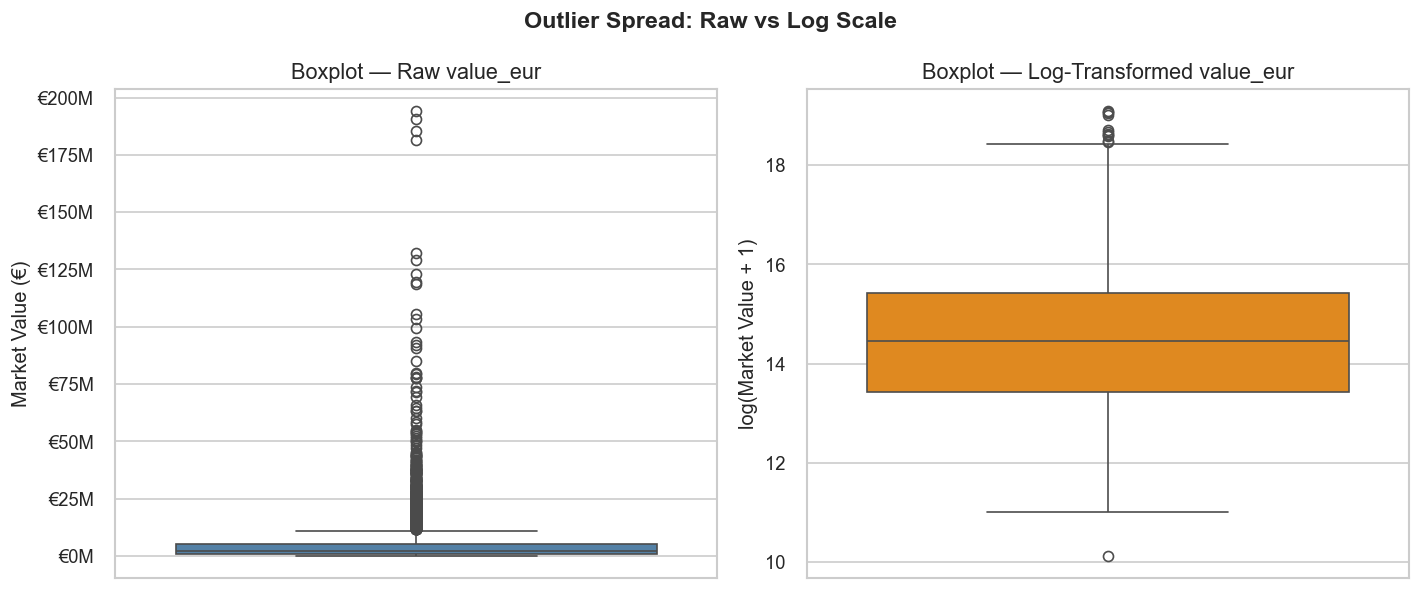

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['value_eur'], ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot — Raw value_eur', fontsize=13)
axes[0].set_ylabel('Market Value (€)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1e6:.0f}M'))

sns.boxplot(y=np.log1p(df['value_eur']), ax=axes[1], color='darkorange')
axes[1].set_title('Boxplot — Log-Transformed value_eur', fontsize=13)
axes[1].set_ylabel('log(Market Value + 1)')

plt.suptitle('Outlier Spread: Raw vs Log Scale', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7 — Outlier Removal Using the IQR Method

### The IQR formula

$$IQR = Q3 - Q1$$

$$\text{Lower fence} = Q1 - 1.5 \times IQR$$
$$\text{Upper fence} = Q3 + 1.5 \times IQR$$

Any observation **outside** these fences is removed.


### Why remove outliers for market value prediction?
Player values like Mbappé's €194M are legitimate, but they are **statistical anomalies**.  
Including them in training makes the model optimize for these rare cases,  
worsening predictions for the **99% of average players** — which is our actual use case.

> We apply IQR on the **raw euro scale** so the fence values stay interpretable.

In [35]:
Q1 = df['value_eur'].quantile(0.25)
Q3 = df['value_eur'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f'Q1 (25th pct)  : €{Q1:>12,.0f}')
print(f'Q3 (75th pct)  : €{Q3:>12,.0f}')
print(f'IQR            : €{IQR:>12,.0f}')
print()
print(f'Lower fence    : €{lower_fence:>12,.0f}  (Q1 - 1.5 × IQR)')
print(f'Upper fence    : €{upper_fence:>12,.0f}  (Q3 + 1.5 × IQR)')
print()

outliers = df[(df['value_eur'] < lower_fence) | (df['value_eur'] > upper_fence)]
print(f'Outliers detected: {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}% of data)')
print()
print('Top 10 highest-value outliers:')
print(outliers[['short_name', 'club_name', 'overall', 'value_eur']]
      .sort_values('value_eur', ascending=False)
      .head(10)
      .to_string(index=False))

Q1 (25th pct)  : €     675,000
Q3 (75th pct)  : €   5,000,000
IQR            : €   4,325,000

Lower fence    : €  -5,812,500  (Q1 - 1.5 × IQR)
Upper fence    : €  11,487,500  (Q3 + 1.5 × IQR)

Outliers detected: 622 rows (12.2% of data)

Top 10 highest-value outliers:
   short_name           club_name  overall   value_eur
    K. Mbappé Paris Saint Germain       91 194000000.0
    K. Mbappé Paris Saint Germain       91 190500000.0
    K. Mbappé Paris Saint Germain       90 185500000.0
    K. Mbappé Paris Saint Germain       91 181500000.0
    Neymar Jr Paris Saint Germain       91 132000000.0
    Neymar Jr Paris Saint Germain       91 129000000.0
    Neymar Jr Paris Saint Germain       92 123000000.0
G. Donnarumma Paris Saint Germain       89 119500000.0
    Neymar Jr Paris Saint Germain       92 118500000.0
    Neymar Jr Paris Saint Germain       92 105500000.0


In [36]:
# Keep only rows within the IQR fences
before_iqr = len(df)
df_clean = df[(df['value_eur'] >= lower_fence) & (df['value_eur'] <= upper_fence)].copy()
after_iqr = len(df_clean)

print(f'Rows before IQR removal : {before_iqr}')
print(f'Rows after  IQR removal : {after_iqr}')
print(f'Rows removed            : {before_iqr - after_iqr}')
print()
print('Post-removal value_eur summary:')
print(df_clean['value_eur'].describe().apply(lambda x: f'€{x:,.0f}').to_string())

Rows before IQR removal : 5080
Rows after  IQR removal : 4458
Rows removed            : 622

Post-removal value_eur summary:
count         €4,458
mean      €2,479,634
std       €2,589,331
min          €25,000
25%         €600,000
50%       €1,400,000
75%       €3,400,000
max      €11,000,000


## Step 8 — Before vs. After Outlier Removal

We visualize the distribution before and after IQR removal to confirm  
the extreme right tail has been clipped and the distribution is more compact.

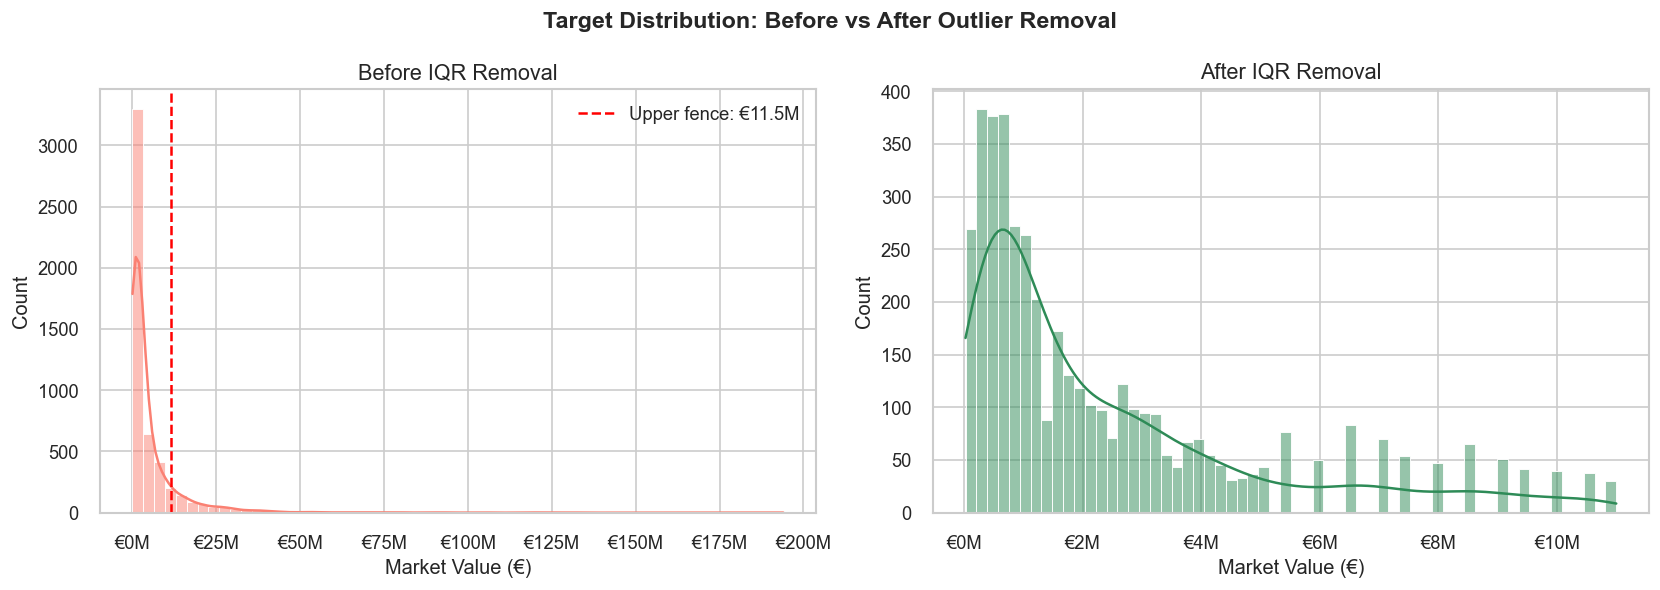

Skewness before: 7.502
Skewness after : 1.500


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before — note the long right tail
sns.histplot(df['value_eur'], kde=True, bins=60, ax=axes[0], color='salmon')
axes[0].axvline(upper_fence, color='red', linestyle='--', linewidth=1.5,
                label=f'Upper fence: €{upper_fence/1e6:.1f}M')
axes[0].set_title('Before IQR Removal', fontsize=13)
axes[0].set_xlabel('Market Value (€)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1e6:.0f}M'))
axes[0].legend()

# After — more compact, better for model training
sns.histplot(df_clean['value_eur'], kde=True, bins=60, ax=axes[1], color='seagreen')
axes[1].set_title('After IQR Removal', fontsize=13)
axes[1].set_xlabel('Market Value (€)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1e6:.0f}M'))

plt.suptitle('Target Distribution: Before vs After Outlier Removal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness before: {df["value_eur"].skew():.3f}')
print(f'Skewness after : {df_clean["value_eur"].skew():.3f}')

## Step 9 — Correlation Analysis

### What is Pearson correlation?

$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \cdot \sum(y_i - \bar{y})^2}}$$

- Range: **−1 to +1**
- **+1** → perfect positive linear relationship
- **0** → no linear relationship
- **−1** → perfect negative linear relationship

We compute correlation of every numeric feature with `value_eur` to get a quick sense of which features matter.  
This is **informal** — the formal, rigorous selection happens in notebook 02.

> **Caveat:** Pearson only captures *linear* relationships.  
> A feature with r = 0.1 could still be very important in a nonlinear model like a neural network.

In [38]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

correlations = df_clean[numeric_cols].corr()['value_eur'].drop('value_eur')
correlations = correlations.sort_values(ascending=False)

print('Top 15 positively correlated features:')
print(correlations.head(15).to_string())
print()
print('Top 5 negatively correlated features:')
print(correlations.tail(5).to_string())

Top 15 positively correlated features:
release_clause_eur          0.991078
overall                     0.768685
wage_eur                    0.699745
movement_reactions          0.642802
potential                   0.597196
mentality_composure         0.543332
passing                     0.491914
dribbling                   0.465530
mentality_vision            0.390540
attacking_short_passing     0.389789
power_shot_power            0.389619
skill_long_passing          0.383042
international_reputation    0.370437
physic                      0.362520
skill_ball_control          0.361574

Top 5 negatively correlated features:
club_jersey_number   -0.182676
club_team_id         -0.190636
league_id            -0.318782
league_level         -0.318782
fifa_update                NaN


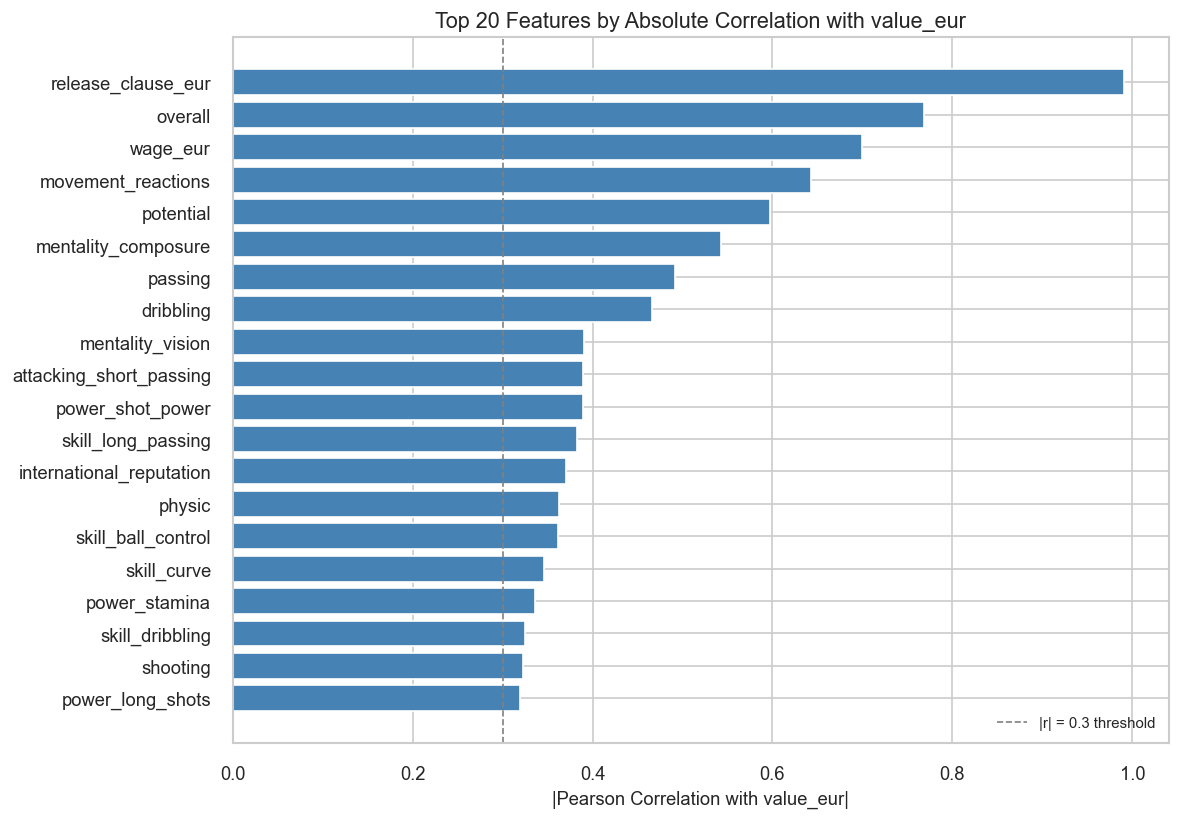

In [39]:
# Bar chart of top 20 features by absolute correlation with value_eur
top20 = correlations.abs().sort_values(ascending=False).head(20)
top20_signed = correlations[top20.index]
colors = ['steelblue' if v > 0 else 'salmon' for v in top20_signed.values]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel('|Pearson Correlation with value_eur|', fontsize=11)
ax.set_title('Top 20 Features by Absolute Correlation with value_eur', fontsize=13)
ax.axvline(0.3, color='gray', linestyle='--', linewidth=1, label='|r| = 0.3 threshold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Step 10 — Correlation Heatmap (Top Features)

A **heatmap** shows pairwise correlations between features — not just each feature vs the target.  
This helps detect **multicollinearity**: when two features are strongly correlated *with each other*.

**Why does multicollinearity matter?**  
If `overall` and `potential` both encode the same information,  
keeping both doesn't add predictive power — but it can destabilize linear models (LASSO, linear regression)  
because the model cannot decide which one to weight.

We use **only the lower triangle** of the matrix (the upper triangle is a mirror — redundant).

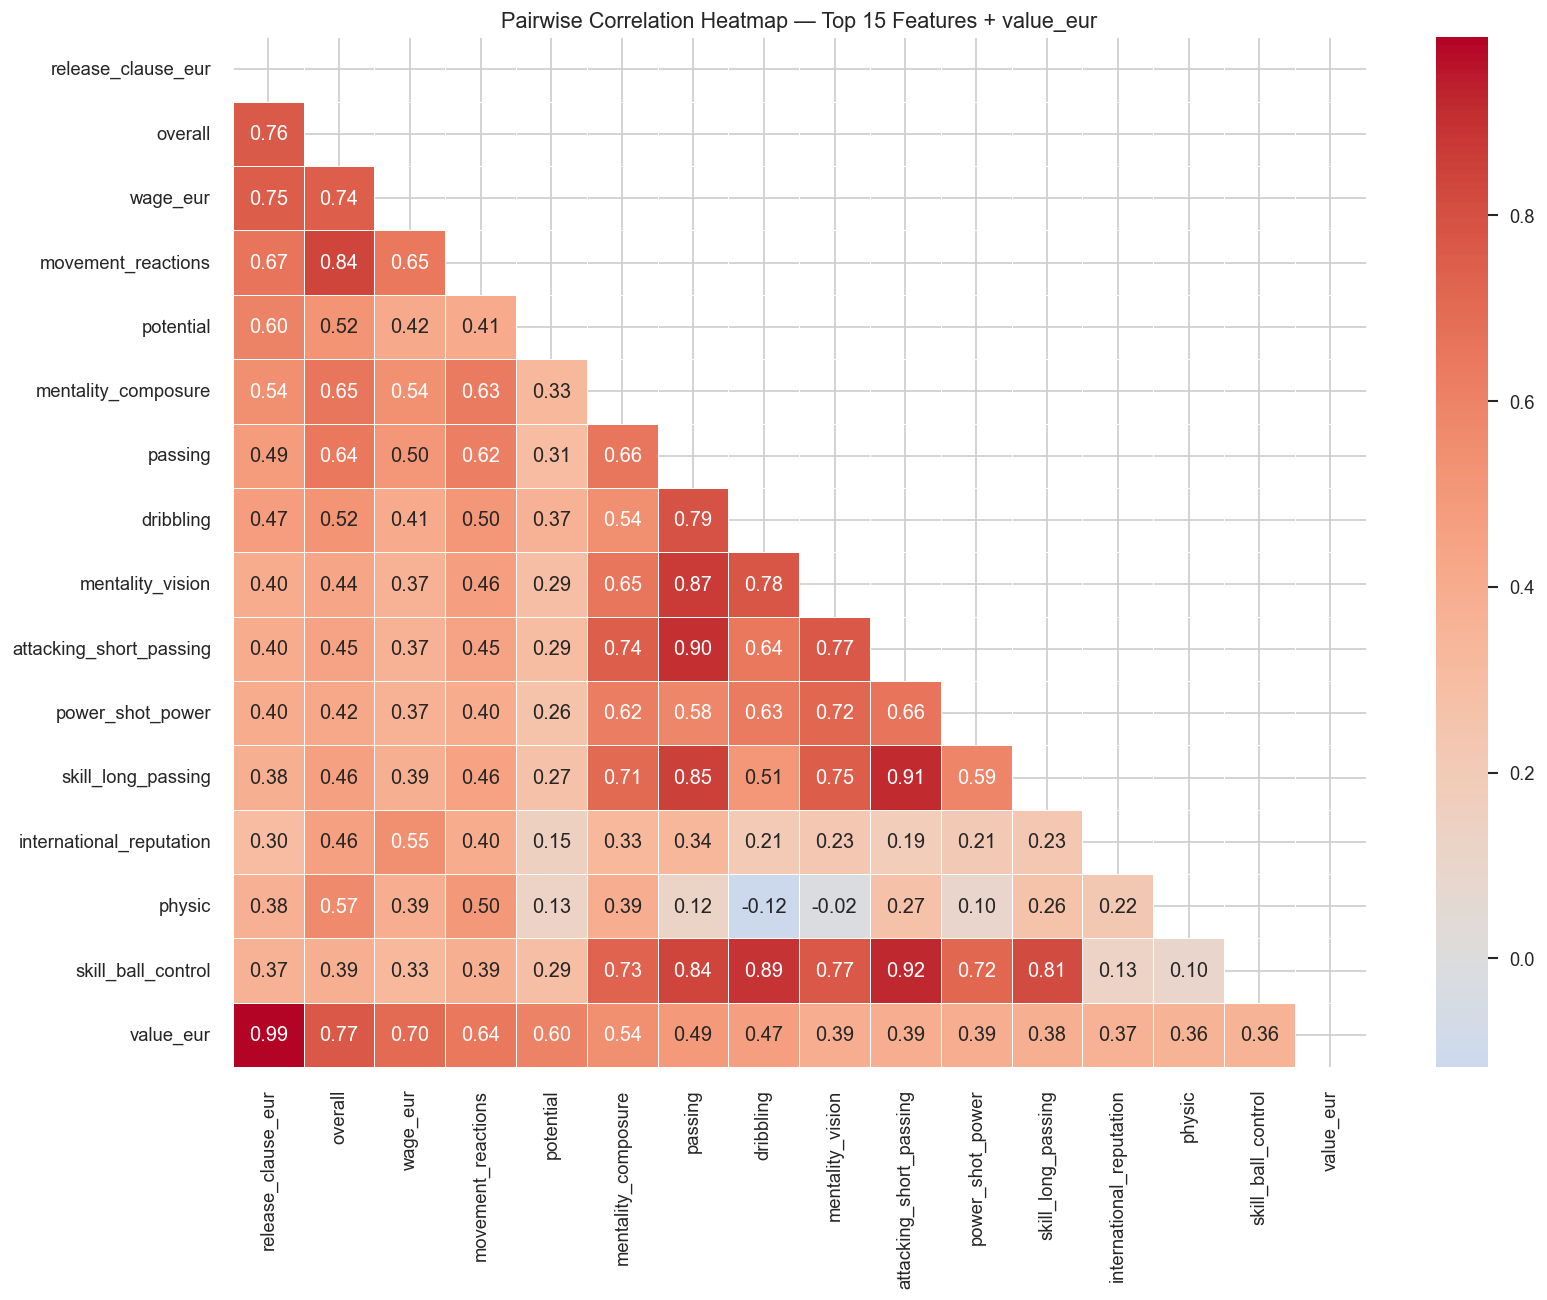

In [40]:
top_features = correlations.abs().sort_values(ascending=False).head(15).index.tolist()
heatmap_cols = top_features + ['value_eur']

corr_matrix = df_clean[heatmap_cols].corr()

# Mask the upper triangle to avoid showing duplicate information
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Pairwise Correlation Heatmap — Top 15 Features + value_eur', fontsize=13)
plt.tight_layout()
plt.show()

## Step 11 — Scatter Plots: Top Features vs. value_eur

A correlation coefficient is a single number — it tells us *how strong* the relationship is,  
but not *what shape* it takes. A scatter plot reveals:

- Is the relationship **truly linear** or is it curved (quadratic, exponential)?
- Are there **clusters** — groups of players that behave differently?
- Are there **outliers** still present even after IQR removal?

`regplot` overlays a linear regression line with a confidence band — if the data curves away from the line, we have nonlinearity.

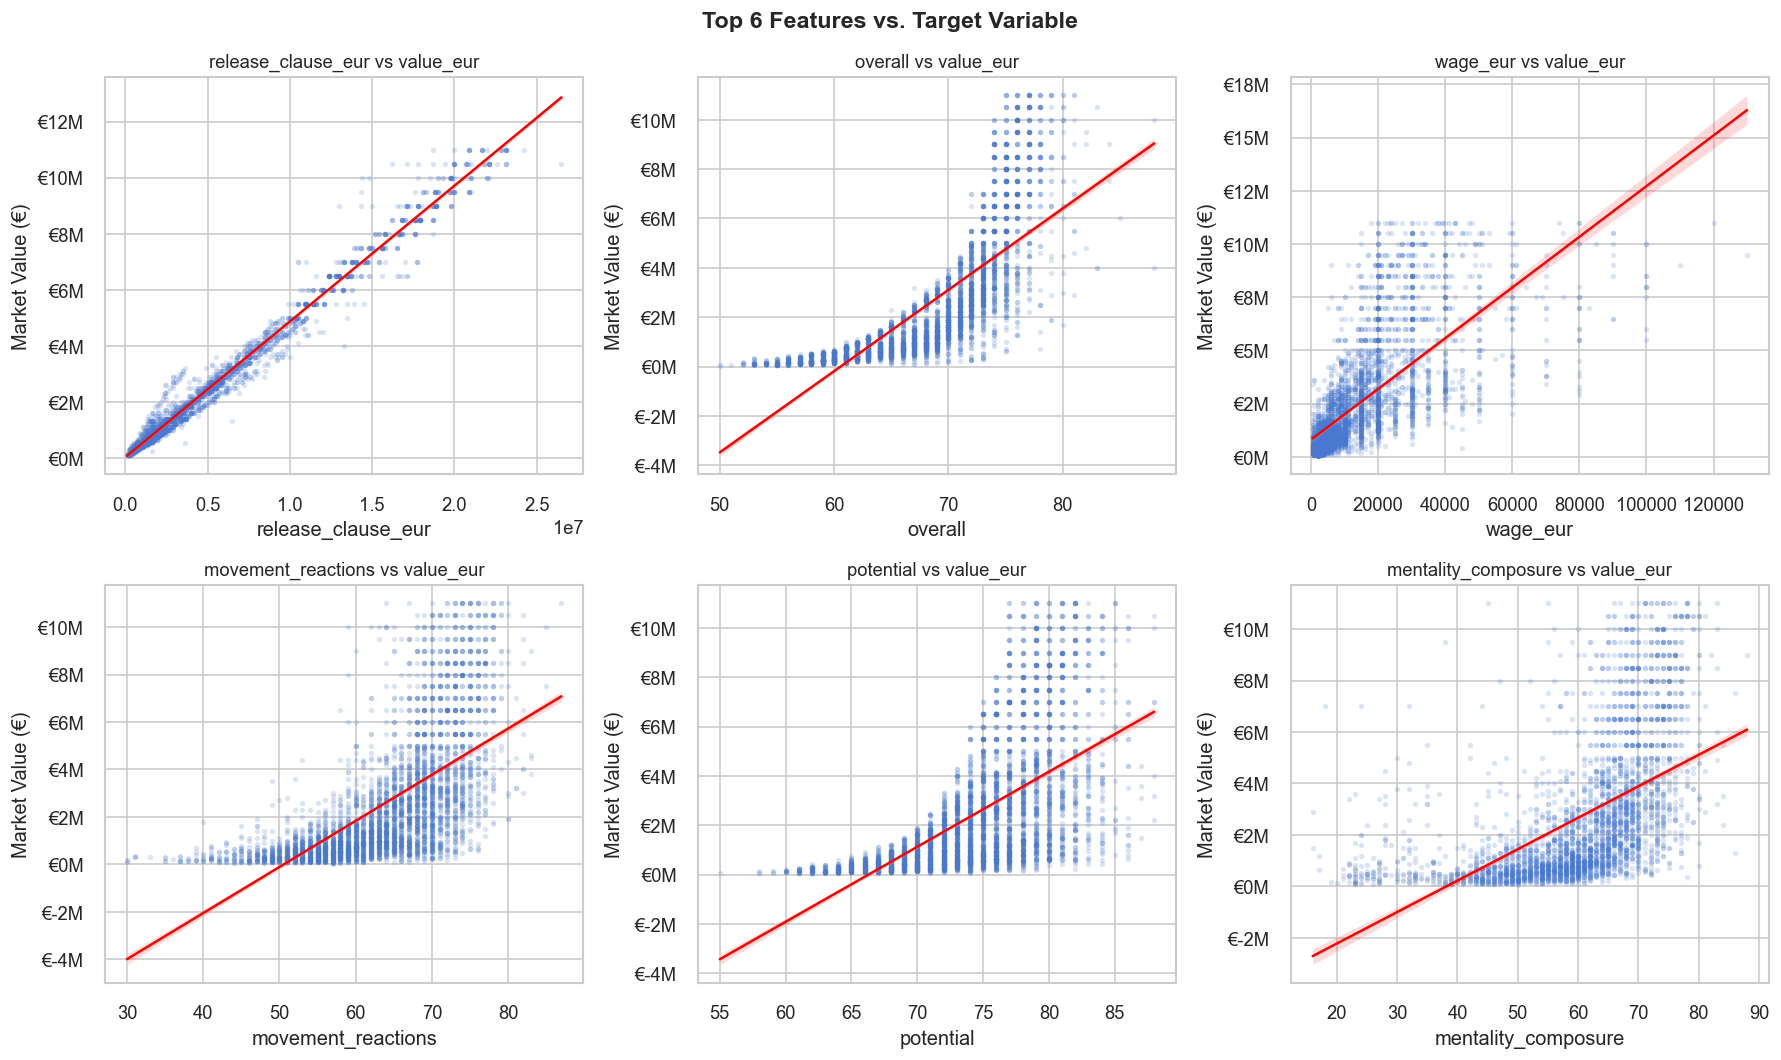

In [41]:
top6_features = correlations.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(top6_features):
    sns.regplot(
        data=df_clean, x=feat, y='value_eur', ax=axes[i],
        scatter_kws={'alpha': 0.2, 's': 10},  # alpha=0.2 prevents overplotting
        line_kws={'color': 'red', 'linewidth': 1.5}
    )
    axes[i].set_title(f'{feat} vs value_eur', fontsize=11)
    axes[i].set_ylabel('Market Value (€)')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1e6:.0f}M'))

plt.suptitle('Top 6 Features vs. Target Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 12 — Market Value by Player Position

Position is a **categorical** variable — players have very different market values depending on their role.  
Forwards generate goals (directly valued by fans/sponsors), so they typically command a premium.  
We extract the **primary position** (first in the list) and compare **median** values by position.

> **Why median and not mean?**  
> Mean is distorted by even one extreme outlier. Median is robust — it represents the typical player's value.

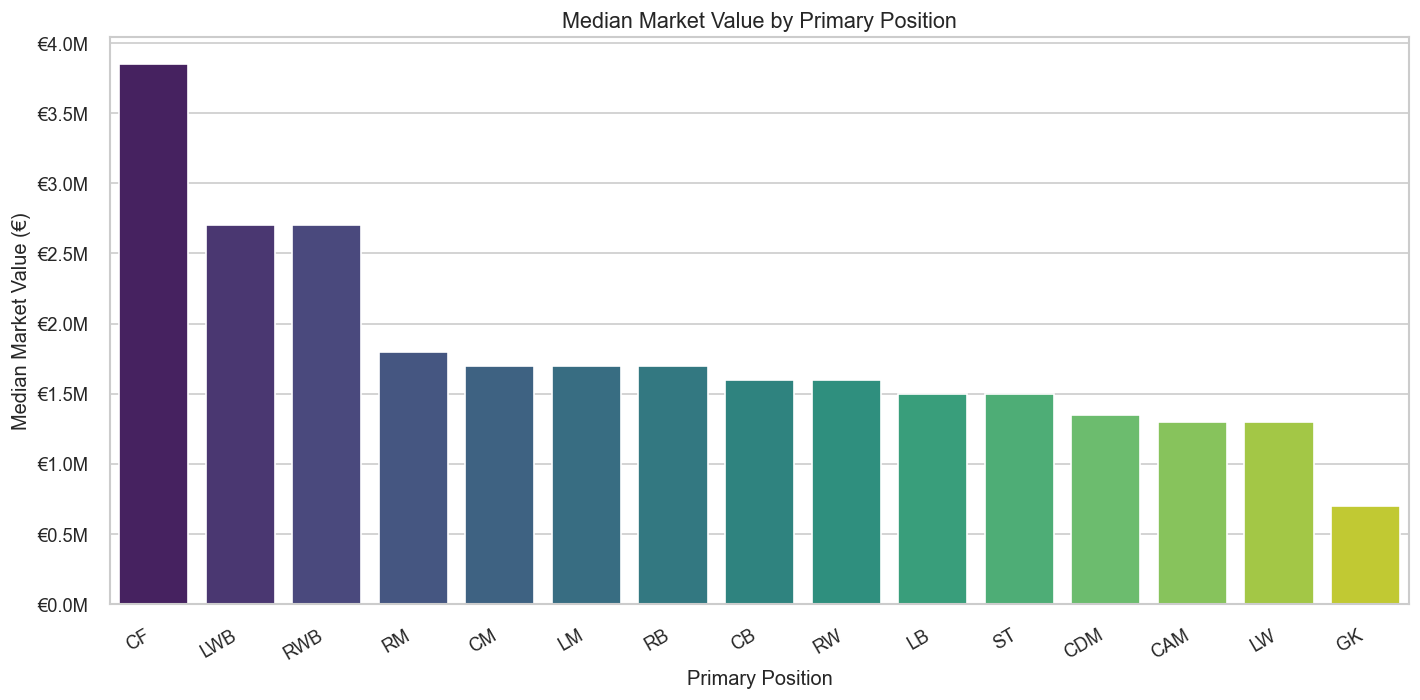

In [42]:
# Extract first position from comma-separated list (e.g., 'ST, LW' → 'ST')
df_clean = df_clean.copy()
df_clean['primary_position'] = df_clean['player_positions'].str.split(',').str[0].str.strip()

pos_value = (df_clean.groupby('primary_position')['value_eur']
             .median()
             .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=pos_value.index, y=pos_value.values, palette='viridis', ax=ax)
ax.set_title('Median Market Value by Primary Position', fontsize=13)
ax.set_xlabel('Primary Position')
ax.set_ylabel('Median Market Value (€)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1e6:.1f}M'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Step 13 — Age vs. Market Value

Age captures the **career lifecycle** of a player:
- Young players (18–22) are valued for their **potential** — clubs pay a premium for upside
- Peak players (24–28) have the highest current ability AND remaining career length
- Older players (32+) depreciate despite still being skilled

This inverted-U relationship (peaks in mid-20s then declines) is known in sports economics  
as the **player lifecycle curve**.

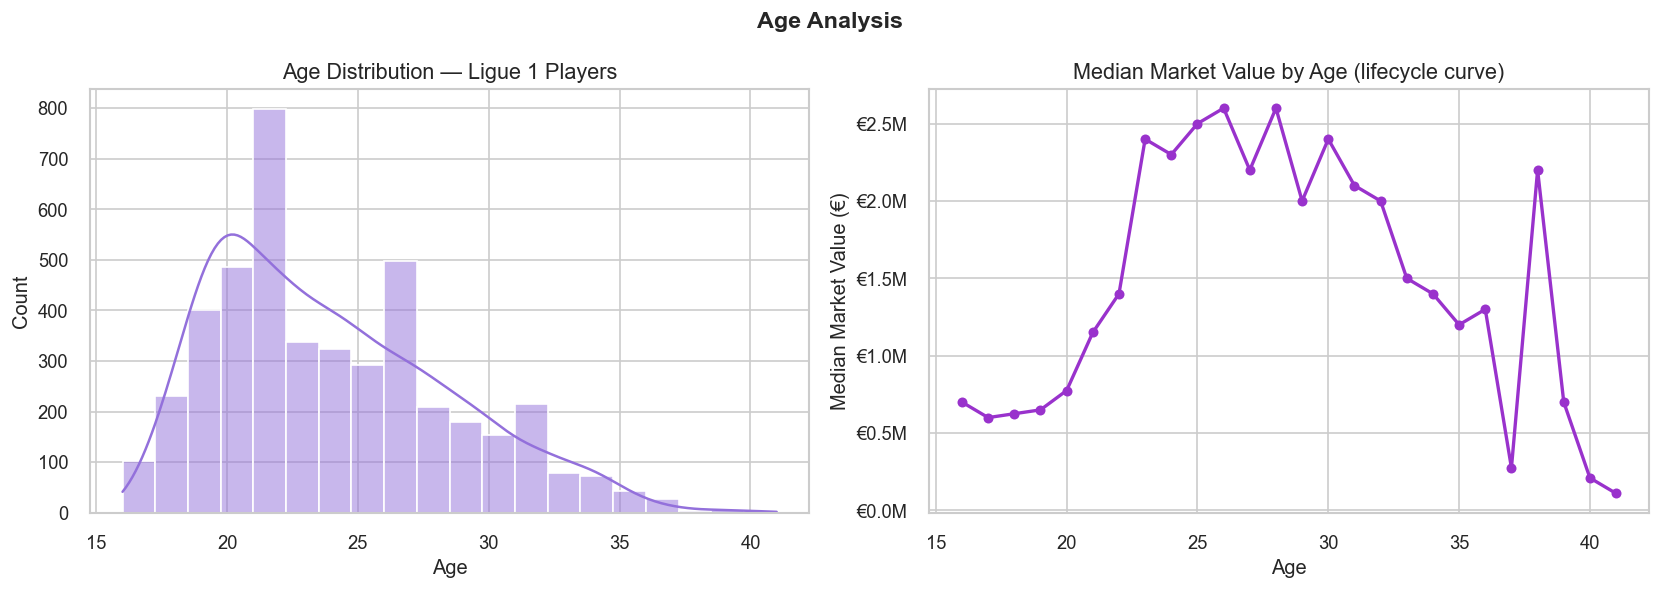

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution of Ligue 1 players
sns.histplot(df_clean['age'], bins=20, kde=True, ax=axes[0], color='mediumpurple')
axes[0].set_title('Age Distribution — Ligue 1 Players', fontsize=13)
axes[0].set_xlabel('Age')

# Median market value by age — should show inverted-U shape
age_value = df_clean.groupby('age')['value_eur'].median()
axes[1].plot(age_value.index, age_value.values, marker='o', color='darkorchid', linewidth=2)
axes[1].set_title('Median Market Value by Age (lifecycle curve)', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Median Market Value (€)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1e6:.1f}M'))

plt.suptitle('Age Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 14 — Save the Cleaned Dataset

We save `df_clean` as `ligue1_clean.csv` so all subsequent notebooks (02–05)  
start from the **same clean, outlier-free baseline**.

This ensures **reproducibility**: anyone running the pipeline gets identical inputs at every stage.

In [44]:
output_path = '../data/ligue1_clean.csv'
df_clean.to_csv(output_path, index=False)

print(f'Saved to       : {output_path}')
print(f'Final shape    : {df_clean.shape}')
print(f'value_eur range: €{df_clean["value_eur"].min():,.0f}  →  €{df_clean["value_eur"].max():,.0f}')

Saved to       : ../data/ligue1_clean.csv
Final shape    : (4458, 110)
value_eur range: €25,000  →  €11,000,000


---
## Summary — What We Did in This Notebook

| Step | Action | Why |
|------|--------|-----|
| 1 | Loaded dataset, filtered to Ligue 1 | Isolate our target domain |
| 2 | Inspected shape, types, null counts | Know what we are working with |
| 3 | Dropped rows where `value_eur` is null | Cannot predict an unknown target |
| 4 | Plotted raw vs log-transformed distribution | Detected strong right skew → log needed |
| 5 | Applied IQR outlier removal (1.5× rule) | Remove extremes that distort model training |
| 6 | Computed Pearson correlations with `value_eur` | Early signal for which features matter |
| 7 | Plotted correlation heatmap | Detect multicollinearity between features |
| 8 | Scatter plots of top 6 features vs target | Verify linearity assumptions |
| 9 | Median value by position and age | Understand domain-driven patterns |
| 10 | Saved `ligue1_clean.csv` | Reproducible baseline for all downstream notebooks |

**Next:** `02_feature_selection.ipynb` — formally select the top 4 features using SelectKBest, LASSO, and Decision Tree importance.